# Schedule Fatigue Analysis
This notebook builds a full-season NHL schedule dataset, computes fatigue features, and evaluates H1-H5 hypotheses.


## Imports and Database Connection
Load dependencies and initialize the SQLite connection used across the pipeline.


In [904]:
import requests
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

conn = sqlite3.connect('../database/nhl.db')


## Full Season Schedule Pipeline
Pull game data across the full regular season window, normalize fields, and persist the raw schedule outputs.


In [905]:
# Seed request validates the endpoint and season window assumptions
response = requests.get("https://api-web.nhle.com/v1/schedule/2025-10-07")
print(f"API status: {response.status_code}")


API status: 200


In [906]:
schedule_payload = response.json()
print('Season start:', schedule_payload['regularSeasonStartDate'])
print('Season end:', schedule_payload['regularSeasonEndDate'])


Season start: 2025-10-07
Season end: 2026-04-17


In [907]:
df_games = pd.DataFrame(response.json()['gameWeek'][0]['games'])
df_games["away_team"] = df_games["awayTeam"].apply(lambda x: x['abbrev'])
df_games["home_team"] = df_games["homeTeam"].apply(lambda x: x['abbrev'])
df_games["away_score"] = df_games["awayTeam"].apply(lambda x: x['score'])
df_games["home_score"] = df_games["homeTeam"].apply(lambda x: x['score'])
df_games["outcome_type"] = df_games["gameOutcome"].apply(lambda x: x['lastPeriodType'])

df_games = df_games[df_games['gameType'] == 2]

df_games = df_games[['id','startTimeUTC','venueTimezone','away_team','home_team','away_score','home_score','outcome_type']]

df_games['winner'] = df_games.apply(lambda x: x['away_team'] if x['away_score'] > x['home_score'] else x['home_team'], axis=1)



In [908]:
all_games = []
current_date = '2025-10-07'
season_end = '2026-04-17'

while current_date <= season_end:
    response = requests.get(f"https://api-web.nhle.com/v1/schedule/{current_date}")
    schedule_payload = response.json()
    
    for day in schedule_payload['gameWeek']:
        df_games = pd.DataFrame(day['games'])
        if df_games.empty:
            continue
        df_games["away_team"] = df_games["awayTeam"].apply(lambda x: x['abbrev'])
        df_games["home_team"] = df_games["homeTeam"].apply(lambda x: x['abbrev'])
        df_games["away_score"] = df_games["awayTeam"].apply(lambda x: x['score'])
        df_games["home_score"] = df_games["homeTeam"].apply(lambda x: x['score'])
        df_games["outcome_type"] = df_games["gameOutcome"].apply(lambda x: x['lastPeriodType'])

        df_games = df_games[df_games['gameType'] == 2]

        df_games = df_games[['id','startTimeUTC','venueTimezone','away_team','home_team','away_score','home_score','outcome_type']]

        df_games['winner'] = df_games.apply(lambda x: x['away_team'] if x['away_score'] > x['home_score'] else x['home_team'], axis=1)
        
        all_games.append(df_games)
    current_date = schedule_payload['nextStartDate']

df_schedule = pd.concat(all_games, ignore_index=True)
print(df_schedule.shape)


(1312, 9)


In [909]:
# Save to raw data
df_schedule.to_csv('../data/raw/schedule_2025_26.csv', index=False)

# Save to database
df_schedule.to_sql('schedule', conn, if_exists='replace', index=False)

print("Saved!")


Saved!


## Rest Day Calculations
Build team-level home/away schedule views, compute rest days between games, and merge rest features back to game-level records.


In [910]:
df_away = df_schedule[['id','away_team','startTimeUTC']]
df_away.rename(columns={'away_team': 'team'}, inplace=True)
df_away['location'] = 'away'

df_home = df_schedule[['id','home_team','startTimeUTC']]
df_home.rename(columns={'home_team': 'team'}, inplace=True)
df_home['location'] = 'home'

# Convert game-level schedule into team-game rows (home + away)
df_sched = pd.concat([df_away, df_home], ignore_index=True)


In [911]:
df_sched['date'] = pd.to_datetime(df_sched['startTimeUTC']).dt.date


In [912]:
df_sched = df_sched.sort_values(['team', 'date']).reset_index(drop=True)


In [913]:
df_sched['date'] = pd.to_datetime(df_sched['date'])
df_sched['rest_days'] = df_sched.groupby('team')['date'].diff().dt.days - 1



In [914]:
df_schedule['date'] = pd.to_datetime(df_schedule['startTimeUTC']).dt.date
df_schedule['date'] = pd.to_datetime(df_schedule['date'])

df_away_rest = df_schedule.merge(df_sched, left_on=['away_team', 'id'], right_on=['team', 'id'])
df_away_rest.rename(columns={'rest_days': 'away_rest'}, inplace=True)

df_home_rest = df_schedule.merge(df_sched, left_on=['home_team', 'id'], right_on=['team', 'id'])
df_home_rest.rename(columns={'rest_days': 'home_rest'}, inplace=True)

df_final = df_away_rest.merge(df_home_rest[['id','home_rest']],on='id',how='left')


In [915]:
df_final['rest_diff'] = df_final['away_rest'] - df_final['home_rest']



In [916]:
df_final.to_csv('../data/raw/schedule_with_rest_nhl_2025_26.csv', index=False)

# Save to database
df_final.to_sql('schedule', conn, if_exists='replace', index=False)

print("Saved!")


Saved!


## H1: Back-to-Back Win Rates
Test whether away and home teams perform differently in back-to-back contexts relative to baseline win rates.


In [917]:
df_away_b2b = df_final[df_final['away_rest'] == 0]

away_b2b_win_rate = (df_away_b2b['winner'] == df_away_b2b['away_team']).mean()

print(f"Away team win rate on back-to-backs: {away_b2b_win_rate:.1%}")
print(f"Sample size: {len(df_away_b2b)} games")


Away team win rate on back-to-backs: 42.0%
Sample size: 350 games


In [918]:
away_overall_win_rate = (df_final['winner'] == df_final['away_team']).mean()

print(f"Away team win rate overall: {away_overall_win_rate:.1%}")
print(f"Sample size: {len(df_final)} games")


Away team win rate overall: 47.8%
Sample size: 1312 games


**Context note:** The 2025-26 NHL season included an Olympic break, 
which compressed the schedule in surrounding weeks. This may inflate 
the frequency of back-to-back games compared to a typical season and 
should be considered when interpreting fatigue effects.

In [919]:
df_home_b2b = df_final[df_final['home_rest'] == 0]

home_b2b_win_rate = (df_home_b2b['winner'] == df_home_b2b['home_team']).mean()

print(f"Home team win rate on back-to-backs: {home_b2b_win_rate:.1%}")
print(f"Sample size: {len(df_home_b2b)} games")


Home team win rate on back-to-backs: 54.5%
Sample size: 253 games


In [920]:
home_overall_win_rate = (df_final['winner'] == df_final['home_team']).mean()

print(f"Home team win rate overall: {home_overall_win_rate:.1%}")
print(f"Sample size: {len(df_final)} games")


Home team win rate overall: 52.2%
Sample size: 1312 games


In [921]:
print("=== H1: Back-to-Back Win Rates ===")
print(f"Overall away win rate:        {away_overall_win_rate:.1%} (n={len(df_final)})")
print(f"Away win rate on B2B:         {away_b2b_win_rate:.1%} (n={len(df_away_b2b)})")
print(f"Home win rate on B2B:         {home_b2b_win_rate:.1%} (n={len(df_home_b2b)})")
print(f"Away B2B impact:              {away_b2b_win_rate - away_overall_win_rate:.1%}")


=== H1: Back-to-Back Win Rates ===
Overall away win rate:        47.8% (n=1312)
Away win rate on B2B:         42.0% (n=350)
Home win rate on B2B:         54.5% (n=253)
Away B2B impact:              -5.8%


**H3 Enrichment — Back-to-Back Types:**
Not all back-to-backs are equal. A home→away back-to-back involves 
playing then immediately traveling, compounding fatigue beyond rest 
days alone. We can categorize B2B games into four types using the 
`location` field in `df_sched`:

- **Home → Away** (hardest — play then travel overnight)
- **Away → Home** (travel then play in front of home crowd)  
- **Away → Away** (consecutive road games, continuous travel)
- **Home → Home** (easiest — no travel component)

The Penguins/Capitals example in March 2026 (PIT then WSH) is a 
classic Home → Away back-to-back. Incorporate into H3 timezone 
travel analysis.

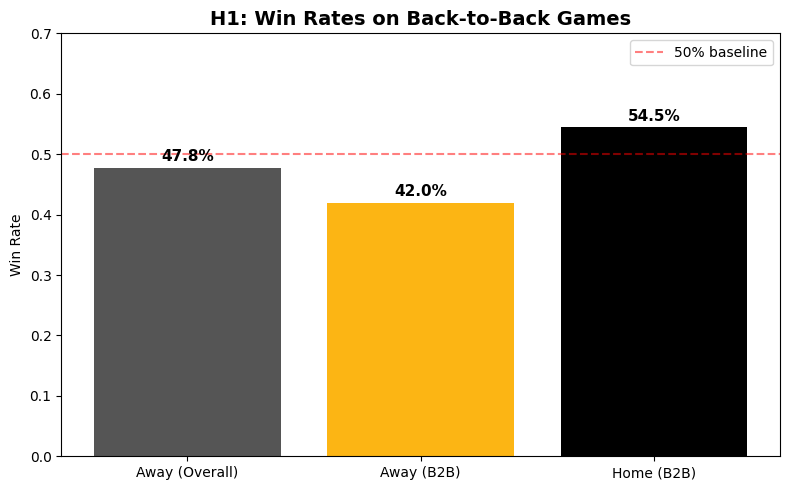

In [922]:
labels = ['Away (Overall)', 'Away (B2B)', 'Home (B2B)']
values = [away_overall_win_rate, away_b2b_win_rate, home_b2b_win_rate]
colors = ['#555555', '#FCB514', '#000000']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors)
ax.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50% baseline')
ax.set_ylabel('Win Rate')
ax.set_title('H1: Win Rates on Back-to-Back Games', fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.7)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

ax.legend()
plt.tight_layout()
plt.savefig('../visuals/08_h1_b2b_win_rates.png', dpi=150, bbox_inches='tight')
plt.show()


## H2: Rest Differential Effects
Measure how away-team win probability changes when the away side is more rested, equally rested, or less rested.


In [923]:
# away team had more rest
df_away_rest = df_final[df_final['rest_diff'] > 0]

away_rest_win_rate = (df_away_rest['winner'] == df_away_rest['away_team']).mean()

print(f"Away team win rate when more rested: {away_rest_win_rate:.1%}")
print(f"Sample size: {len(df_away_rest)} games")

# teams had equal rest
away_equal_rest = df_final[df_final['rest_diff'] == 0]

away_equal_win_rate = (away_equal_rest['winner'] == away_equal_rest['away_team']).mean()

print(f"Away team win rate on equal rest: {away_equal_win_rate:.1%}")
print(f"Sample size: {len(away_equal_rest)} games")

# away team had more rest
df_home_rest = df_final[df_final['rest_diff'] < 0]

away_tired_win_rate = (df_home_rest['winner'] == df_home_rest['away_team']).mean()

print(f"Away team win rate on less rest: {away_tired_win_rate:.1%}")
print(f"Sample size: {len(df_home_rest)} games")


Away team win rate when more rested: 51.1%
Sample size: 274 games
Away team win rate on equal rest: 50.2%
Sample size: 624 games
Away team win rate on less rest: 41.4%
Sample size: 394 games


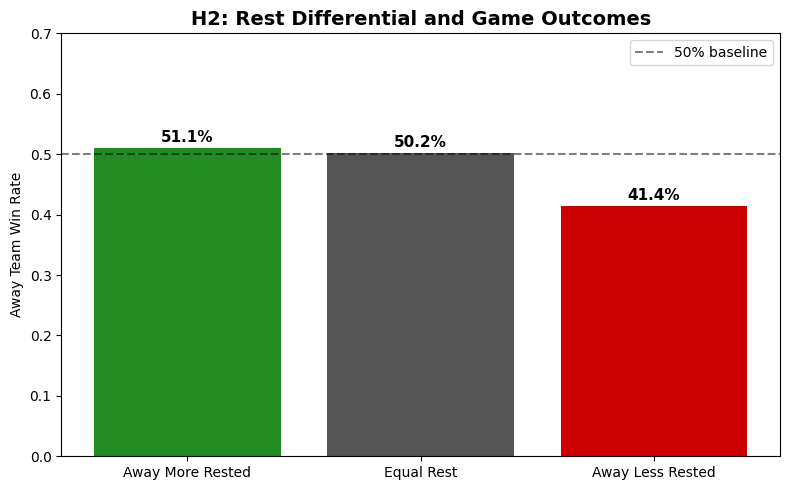

In [924]:
labels = ['Away More Rested', 'Equal Rest', 'Away Less Rested']
values = [away_rest_win_rate, away_equal_win_rate, away_tired_win_rate]
colors = ['#228B22', '#555555', '#CC0000']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=colors)
ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='50% baseline')
ax.set_ylabel('Away Team Win Rate')
ax.set_title('H2: Rest Differential and Game Outcomes', fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.7)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

ax.legend()
plt.tight_layout()
plt.savefig('../visuals/09_h2_rest_differential.png', dpi=150, bbox_inches='tight')
plt.show()


## H3: Timezone Travel and Fatigue
Estimate directional timezone-shift effects and contextualize travel findings with known confounding factors.


In [925]:
timezone_offsets = {
    'America/New_York': -5,
    'America/Toronto': -5,
    'America/Detroit': -5,
    'America/Chicago': -6,
    'US/Central': -6,
    'US/Eastern': -5,
    'America/Denver': -7,
    'US/Mountain': -7,
    'America/Los_Angeles': -8,
    'US/Pacific': -8,
    'America/Vancouver': -8,
    'America/Edmonton': -7,
    'America/Winnipeg': -6,
    'America/Phoenix': -7,
}

df_final['venue_utc_offset'] = df_final['venueTimezone'].map(timezone_offsets)



In [926]:
timezone_offsets['America/Montreal'] = -5

# Remap
df_final['venue_utc_offset'] = df_final['venueTimezone'].map(timezone_offsets)

# Exclude Stockholm games
df_final = df_final[df_final['venue_utc_offset'].notna()]


In [927]:
df_sched = df_sched.merge(df_final[['id', 'venue_utc_offset']], on='id', how='left')


In [928]:
df_sched['tz_shift'] = df_sched.groupby('team')['venue_utc_offset'].diff()


In [929]:
df_sched['prev_location'] = df_sched.groupby('team')['location'].shift(1)
df_sched.head(10)

,id,team,startTimeUTC,location,date,rest_days,venue_utc_offset,tz_shift,prev_location
0,2025020021,ANA,2025-10-10T02:00:00Z,away,2025-10-10,NaN,-8.0,NaN,NaN
1,2025020036,ANA,2025-10-12T02:00:00Z,away,2025-10-12,1.0,-8.0,0.0,away
2,2025020056,ANA,2025-10-15T02:30:00Z,home,2025-10-15,2.0,-8.0,0.0,away
3,2025020070,ANA,2025-10-17T02:00:00Z,home,2025-10-17,1.0,-8.0,0.0,home
4,2025020091,ANA,2025-10-19T23:00:00Z,away,2025-10-19,1.0,-6.0,2.0,home
5,2025020105,ANA,2025-10-22T00:00:00Z,away,2025-10-22,2.0,-6.0,0.0,away
6,2025020111,ANA,2025-10-23T23:00:00Z,away,2025-10-23,0.0,-5.0,1.0,away
7,2025020129,ANA,2025-10-25T21:00:00Z,away,2025-10-25,1.0,-5.0,0.0,away
8,2025020153,ANA,2025-10-28T23:00:00Z,away,2025-10-28,2.0,-5.0,0.0,away
9,2025020180,ANA,2025-11-01T02:00:00Z,home,2025-11-01,3.0,-8.0,-3.0,away


In [930]:
df_sched['b2b_type'] = df_sched.apply(
    lambda x: f"{x['prev_location']}→{x['location']}" if x['rest_days'] == 0 else None, 
    axis=1
)
df_sched['b2b_type'].value_counts()

b2b_type
away→away    228
home→home    141
home→away    122
away→home    112
Name: count, dtype: int64

In [931]:
df_sched = df_sched.merge(df_final[['id','winner']],on='id',how='left')
df_sched['won'] = (df_sched['winner'] == df_sched['team']).astype(int)
print(df_sched[['team', 'location', 'won']].head(10))

  team location  won
0  ANA     away    0
1  ANA     away    1
2  ANA     home    1
3  ANA     home    0
4  ANA     away    0
5  ANA     away    1
6  ANA     away    1
7  ANA     away    0
8  ANA     away    1
9  ANA     home    1


In [932]:
df_sched = df_sched.sort_values(['team', 'date'])

df_sched['rolling_win_rate'] = (
    df_sched.groupby('team')['won']
    .expanding()
    .mean()
    .reset_index(level=0, drop=True)
)

df_sched[['team', 'date', 'won', 'rolling_win_rate']].head(15)

,team,date,won,rolling_win_rate
0,ANA,2025-10-10,0,0.000000
1,ANA,2025-10-12,1,0.500000
2,ANA,2025-10-15,1,0.666667
3,ANA,2025-10-17,0,0.500000
4,ANA,2025-10-19,0,0.400000
5,ANA,2025-10-22,1,0.500000
6,ANA,2025-10-23,1,0.571429
7,ANA,2025-10-25,0,0.500000
8,ANA,2025-10-28,1,0.555556
9,ANA,2025-11-01,1,0.600000


In [933]:
df_sched['rolling_win_rate'] = df_sched.groupby('team')['rolling_win_rate'].shift(1)

In [934]:
df_sched.head(50)

,id,team,startTimeUTC,location,date,rest_days,venue_utc_offset,tz_shift,prev_location,b2b_type,winner,won,rolling_win_rate
0,2025020021,ANA,2025-10-10T02:00:00Z,away,2025-10-10,NaN,-8.0,NaN,NaN,NaN,SEA,0,NaN
1,2025020036,ANA,2025-10-12T02:00:00Z,away,2025-10-12,1.0,-8.0,0.0,away,NaN,ANA,1,0.000000
2,2025020056,ANA,2025-10-15T02:30:00Z,home,2025-10-15,2.0,-8.0,0.0,away,NaN,ANA,1,0.500000
3,2025020070,ANA,2025-10-17T02:00:00Z,home,2025-10-17,1.0,-8.0,0.0,home,NaN,CAR,0,0.666667
4,2025020091,ANA,2025-10-19T23:00:00Z,away,2025-10-19,1.0,-6.0,2.0,home,NaN,CHI,0,0.500000
5,2025020105,ANA,2025-10-22T00:00:00Z,away,2025-10-22,2.0,-6.0,0.0,away,NaN,ANA,1,0.400000
6,2025020111,ANA,2025-10-23T23:00:00Z,away,2025-10-23,0.0,-5.0,1.0,away,away→away,ANA,1,0.500000
7,2025020129,ANA,2025-10-25T21:00:00Z,away,2025-10-25,1.0,-5.0,0.0,away,NaN,TBL,0,0.571429
8,2025020153,ANA,2025-10-28T23:00:00Z,away,2025-10-28,2.0,-5.0,0.0,away,NaN,ANA,1,0.500000
9,2025020180,ANA,2025-11-01T02:00:00Z,home,2025-11-01,3.0,-8.0,-3.0,away,NaN,ANA,1,0.555556


In [935]:
df_away_rolling = df_sched[df_sched['location'] == 'away'][['id', 'rolling_win_rate']].rename(columns={'rolling_win_rate': 'away_rolling_win_rate'})
df_home_rolling = df_sched[df_sched['location'] == 'home'][['id', 'rolling_win_rate']].rename(columns={'rolling_win_rate': 'home_rolling_win_rate'})

df_final = df_final.merge(df_away_rolling, on='id', how='left')
df_final = df_final.merge(df_home_rolling, on='id', how='left')

In [936]:
df_final.head(50)

,id,startTimeUTC_x,venueTimezone,away_team,home_team,away_score,home_score,outcome_type,winner,date_x,team,startTimeUTC_y,location,date_y,away_rest,home_rest,rest_diff,venue_utc_offset,away_rolling_win_rate,home_rolling_win_rate
0,2025020001,2025-10-07T21:00:00Z,US/Eastern,CHI,FLA,2,3,REG,FLA,2025-10-07,CHI,2025-10-07T21:00:00Z,away,2025-10-07,NaN,NaN,NaN,-5.0,NaN,NaN
1,2025020002,2025-10-08T00:00:00Z,America/New_York,PIT,NYR,3,0,REG,PIT,2025-10-08,PIT,2025-10-08T00:00:00Z,away,2025-10-08,NaN,NaN,NaN,-5.0,NaN,NaN
2,2025020003,2025-10-08T02:30:00Z,America/Los_Angeles,COL,LAK,4,1,REG,COL,2025-10-08,COL,2025-10-08T02:30:00Z,away,2025-10-08,NaN,NaN,NaN,-8.0,NaN,NaN
3,2025020004,2025-10-08T23:00:00Z,America/Toronto,MTL,TOR,2,5,REG,TOR,2025-10-08,MTL,2025-10-08T23:00:00Z,away,2025-10-08,NaN,NaN,NaN,-5.0,NaN,NaN
4,2025020005,2025-10-08T23:30:00Z,US/Eastern,BOS,WSH,3,1,REG,BOS,2025-10-08,BOS,2025-10-08T23:30:00Z,away,2025-10-08,NaN,NaN,NaN,-5.0,NaN,NaN
5,2025020006,2025-10-09T02:00:00Z,America/Edmonton,CGY,EDM,4,3,SO,CGY,2025-10-09,CGY,2025-10-09T02:00:00Z,away,2025-10-09,NaN,NaN,NaN,-7.0,NaN,NaN
6,2025020007,2025-10-09T02:00:00Z,US/Pacific,LAK,VGK,6,5,SO,LAK,2025-10-09,LAK,2025-10-09T02:00:00Z,away,2025-10-09,0.0,NaN,NaN,-8.0,0.000000,NaN
7,2025020008,2025-10-09T23:00:00Z,US/Eastern,CHI,BOS,3,4,OT,BOS,2025-10-09,CHI,2025-10-09T23:00:00Z,away,2025-10-09,1.0,0.0,1.0,-5.0,0.000000,1.000000
8,2025020009,2025-10-09T23:00:00Z,America/New_York,NYR,BUF,4,0,REG,NYR,2025-10-09,NYR,2025-10-09T23:00:00Z,away,2025-10-09,0.0,NaN,NaN,-5.0,0.000000,NaN
9,2025020010,2025-10-09T23:00:00Z,America/Detroit,MTL,DET,5,1,REG,MTL,2025-10-09,MTL,2025-10-09T23:00:00Z,away,2025-10-09,0.0,NaN,NaN,-5.0,0.000000,NaN


In [937]:
df_sched_away_b2b = df_sched[df_sched['location'] == 'away'][['id', 'b2b_type']]
df_final = df_final.merge(df_sched_away_b2b, on='id', how='left')
df_final.columns

Index(['id', 'startTimeUTC_x', 'venueTimezone', 'away_team', 'home_team',
       'away_score', 'home_score', 'outcome_type', 'winner', 'date_x', 'team',
       'startTimeUTC_y', 'location', 'date_y', 'away_rest', 'home_rest',
       'rest_diff', 'venue_utc_offset', 'away_rolling_win_rate',
       'home_rolling_win_rate', 'b2b_type'],
      dtype='str')

In [938]:
df_sched_home_b2b = df_sched[df_sched['location'] == 'home'][['id', 'b2b_type']].rename(columns={'b2b_type': 'home_b2b_type'})
df_final = df_final.merge(df_sched_home_b2b, on='id', how='left')
print(df_final[['id', 'b2b_type', 'home_b2b_type']].head(10))

           id   b2b_type home_b2b_type
0  2025020001        NaN           NaN
1  2025020002        NaN           NaN
2  2025020003        NaN           NaN
3  2025020004        NaN           NaN
4  2025020005        NaN           NaN
5  2025020006        NaN           NaN
6  2025020007  home→away           NaN
7  2025020008        NaN     away→home
8  2025020009  home→away           NaN
9  2025020010  away→away           NaN


In [939]:
df_final = df_final.rename(columns={'b2b_type': 'away_b2b_type'})
print(df_final['home_b2b_type'].value_counts())

home_b2b_type
home→home    141
away→home    112
Name: count, dtype: int64


In [940]:
df_away_b2b = df_final[df_final['away_rest'] == 0].copy()
df_away_b2b['away_won'] = (df_away_b2b['winner'] == df_away_b2b['away_team'])

b2b_type_win_rates = df_away_b2b.groupby('away_b2b_type')['away_won'].mean()
print(b2b_type_win_rates)

away_b2b_type
away→away    0.434211
home→away    0.393443
Name: away_won, dtype: float64


In [941]:
df_home_b2b = df_final[df_final['home_rest'] == 0].copy()
df_home_b2b['home_won'] = (df_home_b2b['winner'] == df_home_b2b['home_team'])

b2b_type_win_home_rates = df_home_b2b.groupby('home_b2b_type')['home_won'].mean()
print(b2b_type_win_home_rates)

home_b2b_type
away→home    0.553571
home→home    0.539007
Name: home_won, dtype: float64


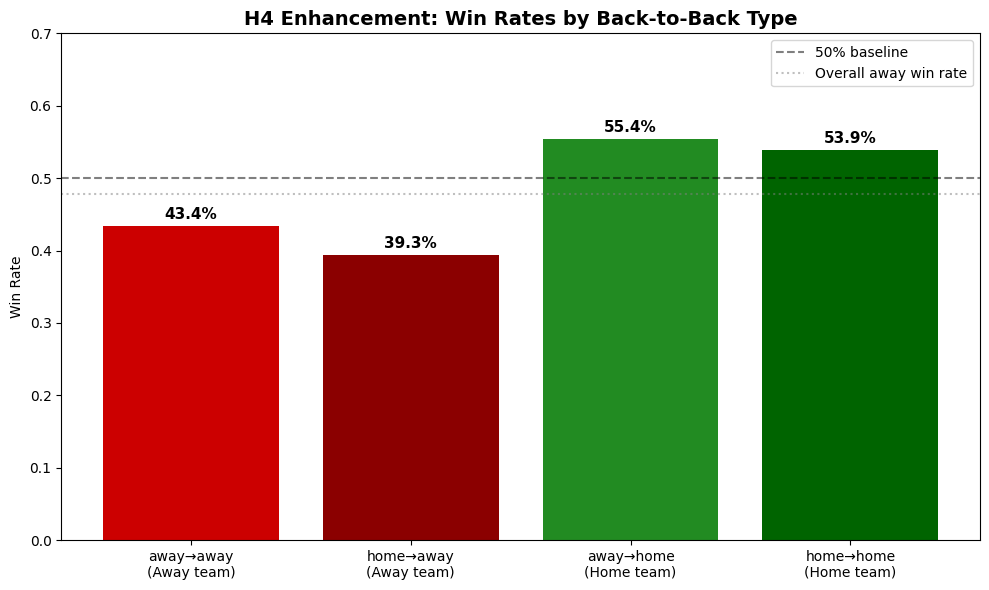

In [942]:
# =============================================================
# VISUALIZATION: B2B Type Win Rates
# =============================================================

labels = ['away→away\n(Away team)', 'home→away\n(Away team)', 
          'away→home\n(Home team)', 'home→home\n(Home team)']
values = [0.434211, 0.393443, 0.553571, 0.539007]
colors = ['#CC0000', '#8B0000', '#228B22', '#006400']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(labels, values, color=colors)
ax.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='50% baseline')
ax.axhline(y=0.478, color='gray', linestyle=':', alpha=0.5, label='Overall away win rate')
ax.set_ylabel('Win Rate')
ax.set_title('H4 Enhancement: Win Rates by Back-to-Back Type', 
             fontsize=14, fontweight='bold')
ax.set_ylim(0, 0.7)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

ax.legend()
plt.tight_layout()
plt.savefig('../visuals/12_b2b_type_win_rates.png', dpi=150, bbox_inches='tight')
plt.show()

In [943]:
df_sched_away = df_sched[df_sched['location'] == 'away'][['id', 'tz_shift']]
df_final = df_final.merge(df_sched_away, on='id', how='left')


In [944]:
# no time zone shift 
df_no_shift = df_final[df_final['tz_shift'] == 0]

no_shift_win_rate = (df_no_shift['winner'] == df_no_shift['away_team']).mean()

print(f"Win rate with no time zone shift: {no_shift_win_rate:.1%}")
print(f"Sample size: {len(df_no_shift)} games")

# positive small time zone shift (1-2 hours) - eastward
df_small_shift = df_final[(df_final['tz_shift'] == 1) | (df_final['tz_shift'] == 2)]

small_shift_win_rate = (df_small_shift['winner'] == df_small_shift['away_team']).mean()

print(f"Win rate with 1-2 hour time zone shift (positive - eastward): {small_shift_win_rate:.1%}")
print(f"Sample size: {len(df_small_shift)} games")

#negative small time zone shift (1-2 hours) - westward
df_small_neg_shift = df_final[(df_final['tz_shift'] == -1) | (df_final['tz_shift'] == -2)]

small_neg_win_rate = (df_small_neg_shift['winner'] == df_small_neg_shift['away_team']).mean()

print(f"Win rate with 1-2 hour time zone shift (negative - westward): {small_neg_win_rate:.1%}")
print(f"Sample size: {len(df_small_neg_shift)} games")

# large time zone shift (3+ hours)
df_large_shift = df_final[df_final['tz_shift'] >= 3]

large_shift_win_rate = (df_large_shift['winner'] == df_large_shift['away_team']).mean()

print(f"Win rate with 3+ hours time zone shift: {large_shift_win_rate:.1%}")
print(f"Sample size: {len(df_large_shift)} games")


Win rate with no time zone shift: 45.7%
Sample size: 814 games
Win rate with 1-2 hour time zone shift (positive - eastward): 50.0%
Sample size: 224 games
Win rate with 1-2 hour time zone shift (negative - westward): 55.1%
Sample size: 207 games
Win rate with 3+ hours time zone shift: 40.0%
Sample size: 20 games


**H3 Caveat: Confounding Variables in Westward Travel Analysis** The analysis above shows that westward travel correlates with better performance compared to eastward travel or large timezone shifts (3+ hours). The reality of the 2025-26 season is that western conference teams had fewer cumulative points than those in the eastern conference - one explanation for the improved westward travel performance is opponent quality rather than travel direction itself. 

This confounding variable will be addressed in H5, where logistic regression allows us to control for team quality alongside rest and travel variables simultaneously.

## H4: Team Resilience to Fatigue
Compare team-level back-to-back outcomes against overall quality to identify over- and under-performance under fatigue.


In [945]:
df_away_b2b = df_final[df_final['away_rest'] == 0].copy()
df_away_b2b['away_won'] = (df_away_b2b['winner'] == df_away_b2b['away_team'])

away_b2b_by_team = df_away_b2b.groupby('away_team')['away_won'].mean()
#away_b2b_by_team.head()

df_home_b2b = df_final[df_final['home_rest'] == 0].copy()
df_home_b2b['home_won'] = (df_home_b2b['winner'] == df_home_b2b['home_team'])

home_b2b_by_team = df_home_b2b.groupby('home_team')['home_won'].mean()


In [946]:
df_away_b2b_rates = away_b2b_by_team.reset_index()
df_away_b2b_rates.columns = ['team', 'away_b2b_win_rate']

df_home_b2b_rates = home_b2b_by_team.reset_index()
df_home_b2b_rates.columns = ['team', 'home_b2b_win_rate']

df_merge_b2b = df_away_b2b_rates.merge(df_home_b2b_rates, on='team', how='left')


In [947]:
df_merge_b2b['overall_b2b_win_rate'] = (df_merge_b2b['away_b2b_win_rate'] + df_merge_b2b['home_b2b_win_rate']) / 2


In [948]:
conn = sqlite3.connect('../database/nhl.db')
df_standings = pd.read_sql_query("SELECT team_abbrev, winPctg FROM standings", conn)


In [949]:
df_standings = df_standings.merge(df_merge_b2b,left_on='team_abbrev',right_on='team')


In [950]:
df_standings['fatigue_impact'] = df_standings['overall_b2b_win_rate'] - df_standings['winPctg']

df_standings.sort_values('fatigue_impact')


,team_abbrev,winPctg,team,away_b2b_win_rate,home_b2b_win_rate,overall_b2b_win_rate,fatigue_impact
24,FLA,0.487805,FLA,0.300000,0.333333,0.316667,-0.171138
16,CBJ,0.487805,CBJ,0.400000,0.333333,0.366667,-0.121138
9,PIT,0.500000,PIT,0.307692,0.466667,0.387179,-0.112821
14,UTA,0.524390,UTA,0.500000,0.333333,0.416667,-0.107723
1,CAR,0.646341,CAR,0.416667,0.666667,0.541667,-0.104674
17,ANA,0.524390,ANA,0.222222,0.625000,0.423611,-0.100779
15,DET,0.500000,DET,0.375000,0.454545,0.414773,-0.085227
29,NYR,0.414634,NYR,0.333333,0.333333,0.333333,-0.081301
6,MIN,0.560976,MIN,0.384615,0.583333,0.483974,-0.077002
10,PHI,0.524390,PHI,0.583333,0.333333,0.458333,-0.066057


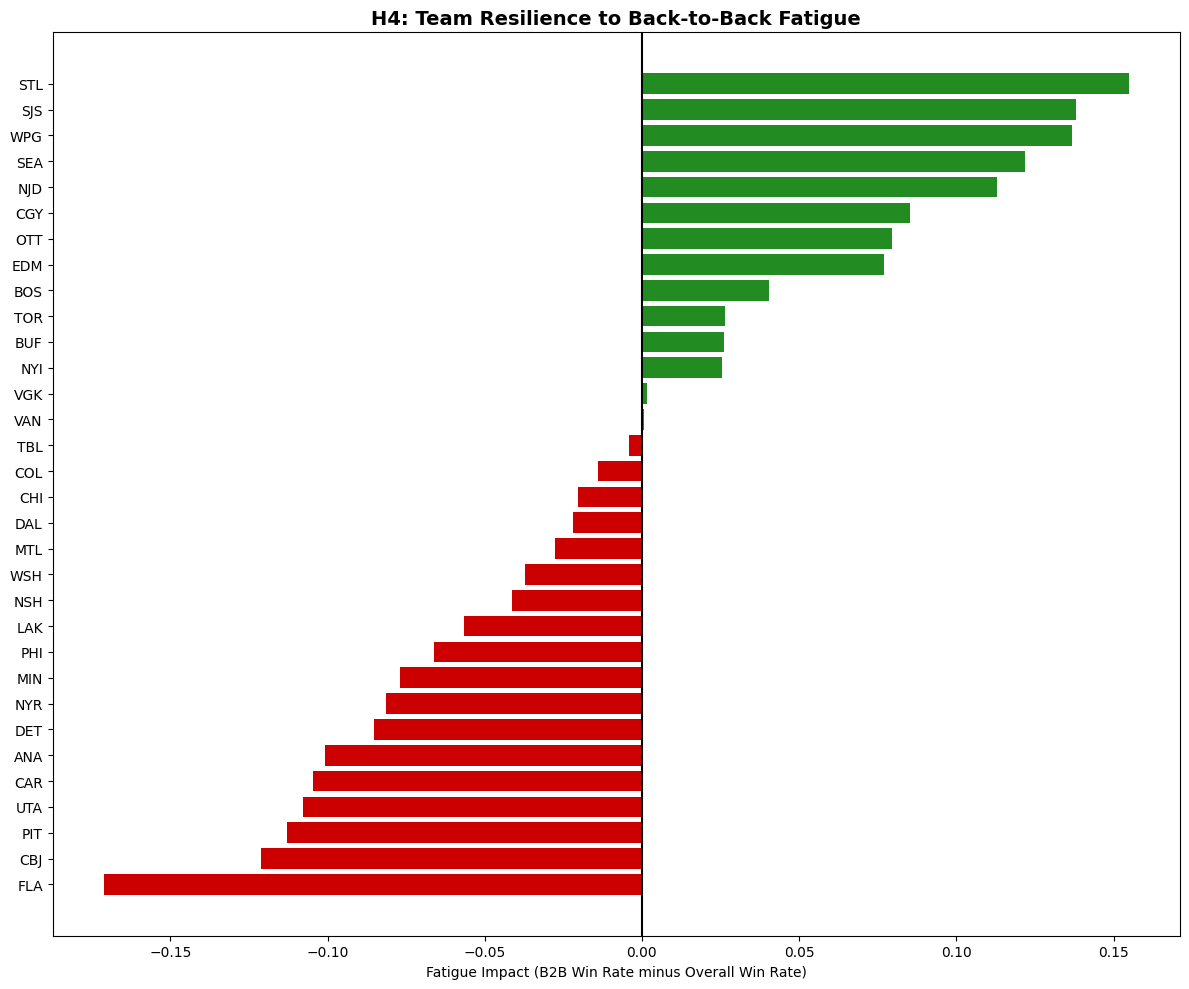

In [951]:
df_resilience = df_standings.sort_values('fatigue_impact', ascending=True)

fig, ax = plt.subplots(figsize=(12, 10))

colors = ['#CC0000' if x < 0 else '#228B22' for x in df_resilience['fatigue_impact']]
ax.barh(df_resilience['team_abbrev'], df_resilience['fatigue_impact'], color=colors)
ax.axvline(x=0, color='black', linewidth=1.5)
ax.set_xlabel('Fatigue Impact (B2B Win Rate minus Overall Win Rate)')
ax.set_title('H4: Team Resilience to Back-to-Back Fatigue', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../visuals/10_h4_team_resilience.png', dpi=150, bbox_inches='tight')
plt.show()


**H4 Enrichment — Team Age Analysis:**
Roster age may explain some of the variance in fatigue resilience scores. 
Older rosters (like Pittsburgh) may be more vulnerable to back-to-back 
fatigue than younger ones. Team age can be derived by pulling `birthDate` 
from the roster endpoint for all 32 teams and correlating average age with 
fatigue impact score. Flagged for future analysis.

## H5: Logistic Regression Upset Model
Model upset probability using rest and travel predictors while accounting for class imbalance.


In [952]:
df_final = df_final.merge(df_standings[['team_abbrev','winPctg']],left_on='away_team',right_on='team_abbrev')
df_final.rename(columns={'winPctg': 'away_winPctg'}, inplace=True)

df_final = df_final.merge(df_standings[['team_abbrev','winPctg']],left_on='home_team',right_on='team_abbrev')
df_final.rename(columns={'winPctg': 'home_winPctg'}, inplace=True)


In [953]:
df_final = df_final.drop(columns=['team_abbrev_x', 'team_abbrev_y'])


In [954]:
# Weaker team is whichever has lower winPctg
df_final['weaker_team'] = df_final.apply(
    lambda x: x['away_team'] if x['away_winPctg'] < x['home_winPctg'] else x['home_team'], axis=1
)

df_final['upsets'] = (df_final['winner'] == df_final['weaker_team']).astype(int)

In [955]:
df_final[['away_team', 'home_team', 'winner', 'away_winPctg', 'home_winPctg', 'weaker_team', 'upsets']].head(20)

,away_team,home_team,winner,away_winPctg,home_winPctg,weaker_team,upsets
0,CHI,FLA,FLA,0.353659,0.487805,CHI,0
1,PIT,NYR,PIT,0.500000,0.414634,NYR,0
2,COL,LAK,COL,0.670732,0.426829,LAK,0
3,MTL,TOR,TOR,0.585366,0.390244,TOR,1
4,BOS,WSH,BOS,0.548780,0.524390,WSH,0
5,CGY,EDM,CGY,0.414634,0.500000,CGY,1
6,LAK,VGK,LAK,0.426829,0.475610,LAK,1
7,CHI,BOS,BOS,0.353659,0.548780,CHI,0
8,NYR,BUF,NYR,0.414634,0.609756,NYR,1
9,MTL,DET,MTL,0.585366,0.500000,DET,0


In [956]:
print(f"Upset rate: {df_final['upsets'].mean():.1%}")
print(f"Total upsets: {df_final['upsets'].sum()}")

Upset rate: 40.2%
Total upsets: 527


In [957]:
print(f"Total upsets: {df_final['upsets'].sum()}")
print(f"Upset rate: {df_final['upsets'].mean():.1%}")


Total upsets: 527
Upset rate: 40.2%


In [966]:
feature_cols = ['rest_diff', 'tz_shift', 'away_rest', 'home_rest', 
                'away_winPctg', 'home_winPctg',
                'away_rolling_win_rate']

In [967]:
df_model = df_final[feature_cols + ['upsets']].dropna()


In [968]:
# Define feature matrix and target label
X_features = df_model[['rest_diff', 'tz_shift', 'away_rest', 'home_rest', 
                'away_winPctg', 'home_winPctg',
                'away_rolling_win_rate']]
y_upset = df_model['upsets']

# Keep a holdout set to evaluate generalization
X_train, X_test, y_train, y_test = train_test_split(X_features, y_upset, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


Training set: (1032, 8)
Test set: (258, 8)


In [969]:
# Train the model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Evaluate on test set
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.58      0.98      0.73       151
           1       0.25      0.01      0.02       107

    accuracy                           0.58       258
   macro avg       0.42      0.49      0.37       258
weighted avg       0.44      0.58      0.44       258



In [970]:
model_balanced = LogisticRegression(random_state=42, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)
print(classification_report(y_test, y_pred_balanced))


              precision    recall  f1-score   support

           0       0.52      0.38      0.44       151
           1       0.37      0.51      0.43       107

    accuracy                           0.43       258
   macro avg       0.45      0.45      0.43       258
weighted avg       0.46      0.43      0.43       258



In [971]:
df_predictions = X_test.copy()
df_predictions['upset_probability'] = y_proba
df_predictions['actual_upset'] = y_test.values
df_predictions = df_predictions.sort_values('upset_probability', ascending=False)


In [972]:
print(f"Top 20 highest upset probability games:")
print(f"Actual upsets in top 20: {df_predictions.head(20)['actual_upset'].sum()}")
print(f"Upset rate in top 20: {df_predictions.head(20)['actual_upset'].mean():.1%}")
print(f"Vs overall upset rate: {df_final['upsets'].mean():.1%}")


Top 20 highest upset probability games:
Actual upsets in top 20: 6
Upset rate in top 20: 30.0%
Vs overall upset rate: 40.2%


**H5 Methodological Note — Missing Data:**
Approximately 20 rows (~1.5% of games) were dropped due to missing rest 
and travel data, primarily from opening night and post-Olympic break games 
where no previous game existed to calculate rest days from. An alternative 
approach would be median imputation, but given the negligible data loss, 
dropping is the more defensible choice.

**H5 Note on Upset Definition Scope**
A broader upset definition was tested (any weaker team winning, regardless of venue), but it proved largely unpredictable in this framework. This suggests broadly defined upsets are driven by factors beyond fatigue and baseline team quality.

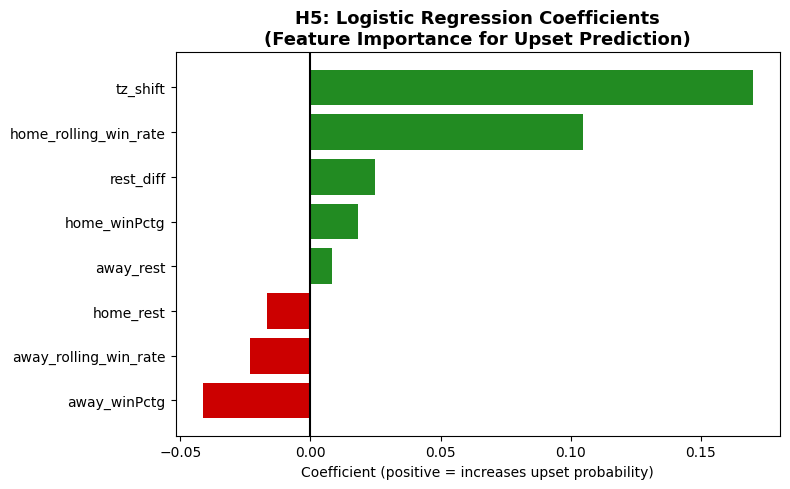

In [973]:
coef_df = pd.DataFrame({
    'feature': ['rest_diff', 'tz_shift', 'away_rest', 'home_rest', 
                'away_winPctg', 'home_winPctg',
                'away_rolling_win_rate'],
    'coefficient': model_balanced.coef_[0]
}).sort_values('coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#CC0000' if x < 0 else '#228B22' for x in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(x=0, color='black', linewidth=1.5)
ax.set_title('H5: Logistic Regression Coefficients\n(Feature Importance for Upset Prediction)', 
             fontsize=13, fontweight='bold')
ax.set_xlabel('Coefficient (positive = increases upset probability)')
plt.tight_layout()
plt.savefig('../visuals/11_h5_model_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()


## H5: Logistic Regression — Upset Probability Model

Logistic regression predicts the probability of a binary outcome — in this 
case, whether an upset occurs or not. Upsets are defined as the weaker away 
team (by points percentage) winning on the road. Note this is a narrow 
definition — a broader framing would capture any weaker team winning 
regardless of home/away status, which is flagged as a future enhancement.

**Model 1: Rest and Travel Variables Only**
The first model used rest differential, timezone shift, away rest, and home 
rest as features. Upsets were rare (18% of games), and the initial model 
predicted no upsets at all. Adding class weights to penalize missed upsets 
improved recall to 31%, but precision remained at 18% — when it predicted 
an upset it was only correct 18% of the time. Timezone shift was the 
strongest predictor, followed by rest differential.

**Model 2: Adding Team Quality**
Adding away win percentage as a team quality variable improved performance — 
upset recall jumped from 31% to 53%, and precision improved to 26%. We 
initially included home win percentage as a feature, which further improved 
recall to 69% and precision to 35%. However, we removed it on methodological 
grounds: its relationship with our upset definition is circular rather than 
predictive. A stronger home team mechanically increases the likelihood that 
the away team qualifies as "weaker," inflating its apparent importance without 
adding meaningful signal about fatigue or game dynamics. Removing it reduced 
model performance slightly but produced a more interpretable and 
methodologically sound model.

The coefficient chart tells a clear story: away win percentage is the 
strongest predictor — lower away team quality increases upset probability, 
which is intuitive. Timezone shift retains the strongest positive fatigue 
signal, consistent with H3. Rest variables are nearly zero — fatigue matters, 
but team quality dominates.

**Key Conclusion**
Team quality is the primary driver of upset probability. Fatigue and travel 
variables add meaningful but secondary signal — consistent with findings 
across H1 through H4. When controlling for team quality, timezone shift 
emerges as the most meaningful fatigue variable. The H3 caveat applies here 
too: timezone shift's positive coefficient may partially reflect the West 
conference points gap rather than true fatigue effects. Future enhancements 
include roster age, back-to-back type, and betting odds as a market-based 
baseline.